In [58]:
import os
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Layer, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr
from tensorflow import keras
import h5py

# Đặt các biến môi trường cho GPU
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

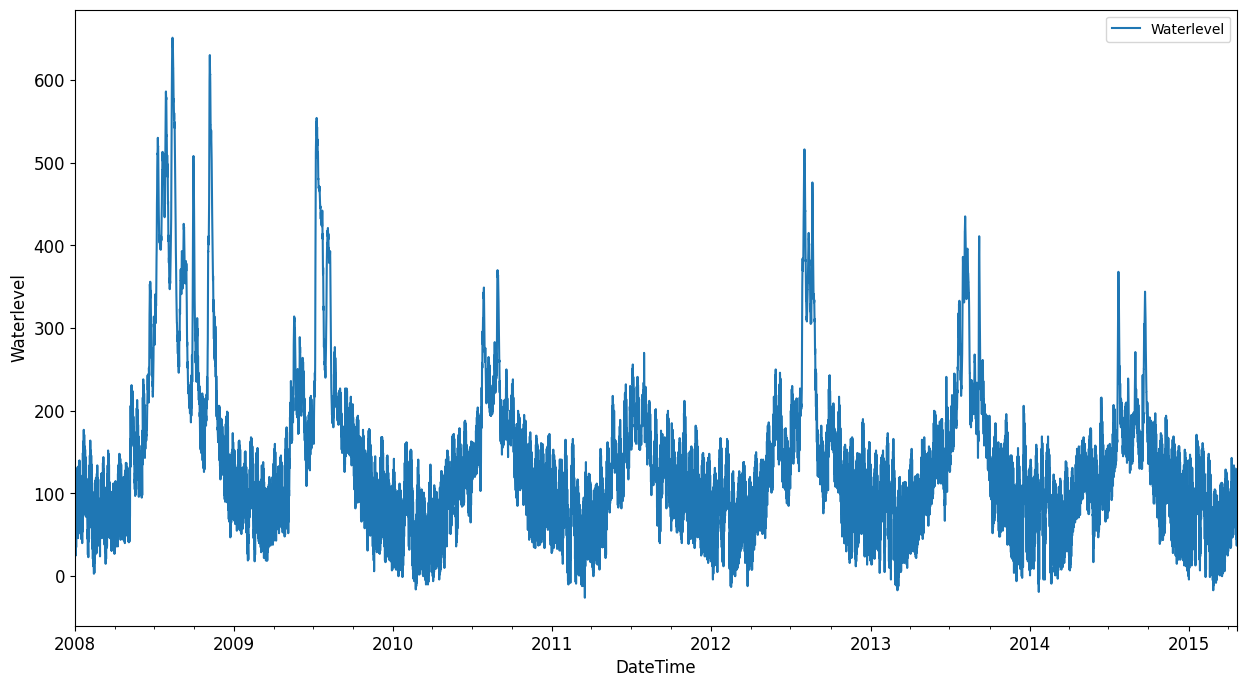

In [59]:
df = pd.read_csv('/kaggle/input/dataset/Impute_misvalues_hungyen.csv')

df['Hour'] = df['Hour'].replace('#NUM!', 0)
df['Hour'] = pd.to_datetime(df['Hour'], format='%H', errors='coerce').dt.time
df['Hour'] = df['Hour'].astype(str)


df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Hour']
        )
df = df.set_index('DateTime')
df.drop(['Date', 'Hour'], 
        axis = 1, inplace = True)

df.plot(y='Waterlevel', subplots=True, figsize=(15, 8), fontsize=12)
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Waterlevel', fontsize=12)
plt.show()


In [60]:
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.85)
train, val, test = df[:train_size].iloc[:, [-1]], df[train_size:val_size].iloc[:, [-1]] , df[val_size:].iloc[:, [-1]]

train, val, test

(                     Waterlevel
 DateTime                       
 2008-01-01 00:00:00        47.0
 2008-01-01 01:00:00        43.0
 2008-01-01 02:00:00        40.0
 2008-01-01 03:00:00        37.0
 2008-01-01 04:00:00        34.0
 ...                         ...
 2013-02-11 05:00:00        86.0
 2013-02-11 06:00:00       100.0
 2013-02-11 07:00:00       115.0
 2013-02-11 08:00:00       128.0
 2013-02-11 09:00:00       134.0
 
 [44842 rows x 1 columns],
                      Waterlevel
 DateTime                       
 2013-02-11 10:00:00       133.0
 2013-02-11 11:00:00       127.0
 2013-02-11 12:00:00       122.0
 2013-02-11 13:00:00       115.0
 2013-02-11 14:00:00       107.0
 ...                         ...
 2014-03-18 14:00:00        46.0
 2014-03-18 15:00:00        54.0
 2014-03-18 16:00:00        61.0
 2014-03-18 17:00:00        65.0
 2014-03-18 18:00:00        65.0
 
 [9609 rows x 1 columns],
                      Waterlevel
 DateTime                       
 2014-03-18 19:00:0

In [61]:
train.shape, val.shape, test.shape

((44842, 1), (9609, 1), (9610, 1))

Text(0, 0.5, 'Waterlevel')

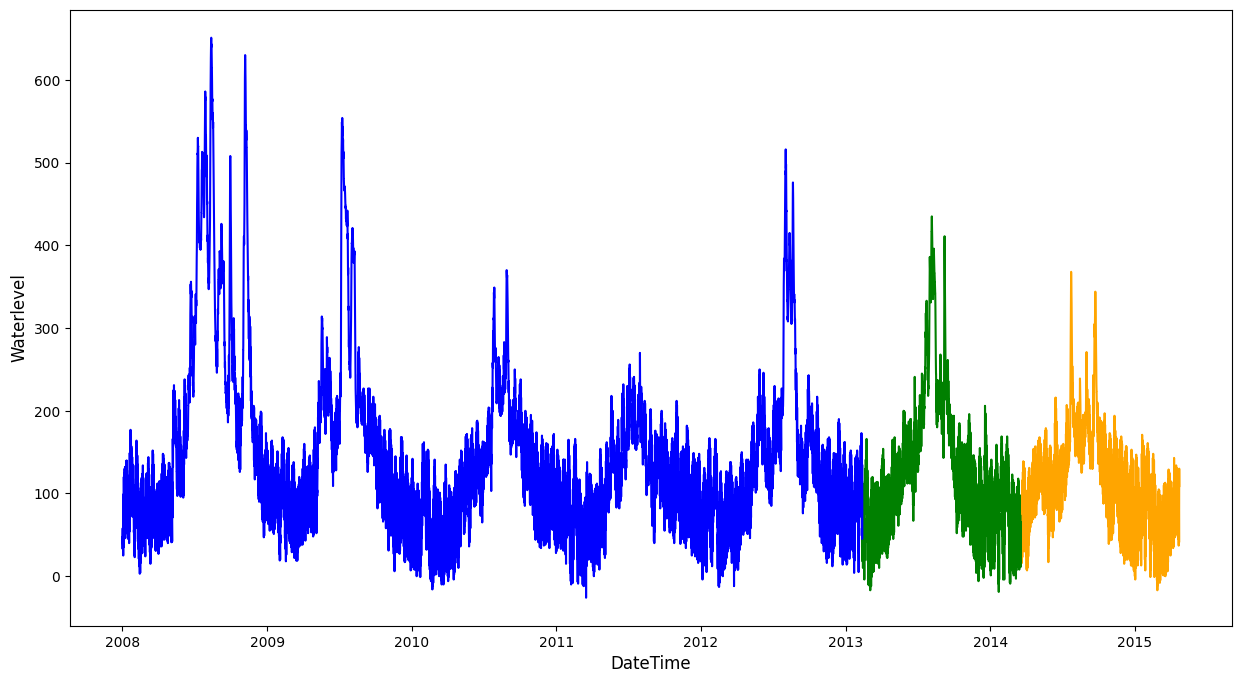

In [62]:
plt.figure(figsize = (15,8))
plt.plot(test.index, test['Waterlevel'], label = "test", color = 'orange')
plt.plot(val.index, val['Waterlevel'], label = "val", color = 'green')
plt.plot(train.index, train['Waterlevel'], label = "train" , color = 'blue')
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Waterlevel', fontsize=12)

In [63]:
scaler = MinMaxScaler()
train['Waterlevel'] = scaler.fit_transform(train)
val['Waterlevel'] = scaler.transform(val)
test['Waterlevel'] = scaler.transform(test)

In [64]:
train_data = train.values
val_data = val.values
test_data = test.values

In [65]:
timesteps = 18

In [66]:
train_data_timesteps=np.array([[j for j in train_data[i:i+timesteps]] 
                               for i in range(0,len(train_data)-timesteps+1)])[:,:,0]
val_data_timesteps=np.array([[j for j in val_data[i:i+timesteps]] 
                             for i in range(0,len(val_data)-timesteps+1)])[:,:,0]
test_data_timesteps=np.array([[j for j in test_data[i:i+timesteps]] 
                              for i in range(0,len(test_data)-timesteps+1)])[:,:,0]


In [67]:
x_train, y_train = train_data_timesteps[:,:timesteps-1],train_data_timesteps[:,[timesteps-1]]
x_val, y_val = val_data_timesteps[:,:timesteps-1],val_data_timesteps[:,[timesteps-1]]
x_test, y_test = test_data_timesteps[:,:timesteps-1],test_data_timesteps[:,[timesteps-1]]

x_train, y_train

(array([[0.10782866, 0.10192024, 0.09748892, ..., 0.11816839, 0.11225997,
         0.10782866],
        [0.10192024, 0.09748892, 0.09305761, ..., 0.11225997, 0.10782866,
         0.10487445],
        [0.09748892, 0.09305761, 0.08862629, ..., 0.10782866, 0.10487445,
         0.10192024],
        ...,
        [0.22451994, 0.211226  , 0.19793205, ..., 0.14327917, 0.16543575,
         0.18611521],
        [0.211226  , 0.19793205, 0.18611521, ..., 0.16543575, 0.18611521,
         0.20827179],
        [0.19793205, 0.18611521, 0.17282127, ..., 0.18611521, 0.20827179,
         0.22747415]]),
 array([[0.10487445],
        [0.10192024],
        [0.09896603],
        ...,
        [0.20827179],
        [0.22747415],
        [0.23633678]]))

In [68]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    squared_error = np.mean((y_true - y_pred)**2)

    r, _ = pearsonr(y_true, y_pred)
    
    T = len(y_true)
    max_x = max(y_true)
    min_x = min(y_true)
    
    sim_sum = 0
    for i in range(T):
        sim_sum += 1 / (1 + abs(y_pred[i] - y_true[i]) / (max_x - min_x))
    sim = sim_sum / T
    
    sd_y = np.std(y_pred)
    sd_x = np.std(y_test)
    fsd = 2 * np.abs(sd_y - sd_x) / (sd_y + sd_x)
    
    nse = 1 - (np.sum((y_pred - y_true) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'MSE' : squared_error,
        'R': r,
        'SIM': sim,
        'FSD': fsd,
        'NSE': nse
    }

In [69]:
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], input_shape[-1]),
                                 initializer='uniform', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[-1],),
                                 initializer='uniform', trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = x * a
        return tf.reduce_sum(output, axis=1)

In [70]:
model = Sequential()

model.add(Input(shape=(timesteps, 1)))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(AttentionLayer())
model.add(AttentionLayer())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

# Huấn luyện mô hình
history = model.fit(x_train, y_train, epochs=100, batch_size=15, validation_data=(x_val, y_val), callbacks=[early_stopping])

Epoch 1/100
2989/2989 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - loss: 0.0033 - val_loss: 7.5595e-04
Epoch 2/100
2989/2989 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 5.1142e-04 - val_loss: 1.6847e-04
Epoch 3/100
2989/2989 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 3.9759e-04 - val_loss: 2.7041e-04
Epoch 4/100
2989/2989 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 3.2258e-04 - val_loss: 7.2166e-04
Epoch 5/100
2989/2989 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 2.8823e-04 - val_loss: 3.9354e-04
Epoch 6/100
2989/2989 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 2.4897e-04 - val_loss: 5.3687e-04
Epoch 7/100
2989/2989 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 2.2777e-04 - val_loss: 1.3565e-04
Epoch 8/100
2989/2989 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 2.0779e-04 - val_loss: 0.0012
Epoch 9/100
2989/2989 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.9239e-04 - val_loss: 4.2571e-04
Epoch 10/100
2989/2989 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.7782e-04 - val_loss: 1.5640e-04
Epoch 11/100
2989/2989 ━━━━━━━━━━━━

In [71]:
# model.save('CNN_AM.h5')
# model = models.load_model('CNN_AM.h5')
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 18, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 18, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 18, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 18, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 18, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 18, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 18, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 18, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_6               │ (None, 128)            │        16,512 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_7               │ (None)                 │        16,512 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,669 (1.62 MB)

 Trainable params: 141,633 (553.25 KB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 283,268 (1.08 MB)

In [72]:
time = 28
hours = 120
pred = []

def forecast(model, hours, time):
    pred = []
    # current_window = x_val[-1,:].tolist()
    current_window = x_test[time,:].tolist()
    for i in range(hours):
        # Chuyển current_window thành numpy array khi gọi predict
        y_pred = model.predict(np.asarray([current_window]))[0]
        pred.append(float(y_pred[0]))
        current_window.pop(0)
        current_window.append(pred[-1])
    pred_array = np.array(pred).reshape(-1, 1)
    return pred_array

y_fc = forecast(model, hours, time)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 868ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━

In [73]:
y_pred = model.predict(x_test[time:])

299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [74]:
y_test_original = scaler.inverse_transform(y_test)
y_pred_original = scaler.inverse_transform(y_pred)
y_fc_original = scaler.inverse_transform(y_fc)

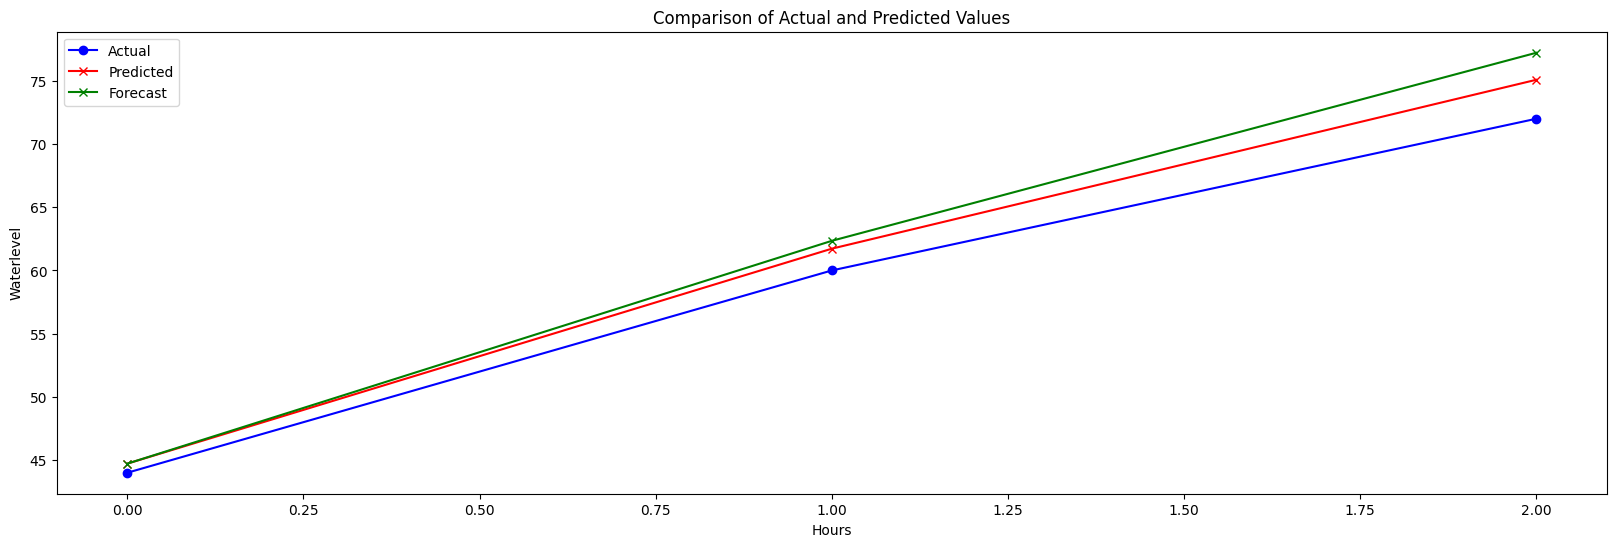

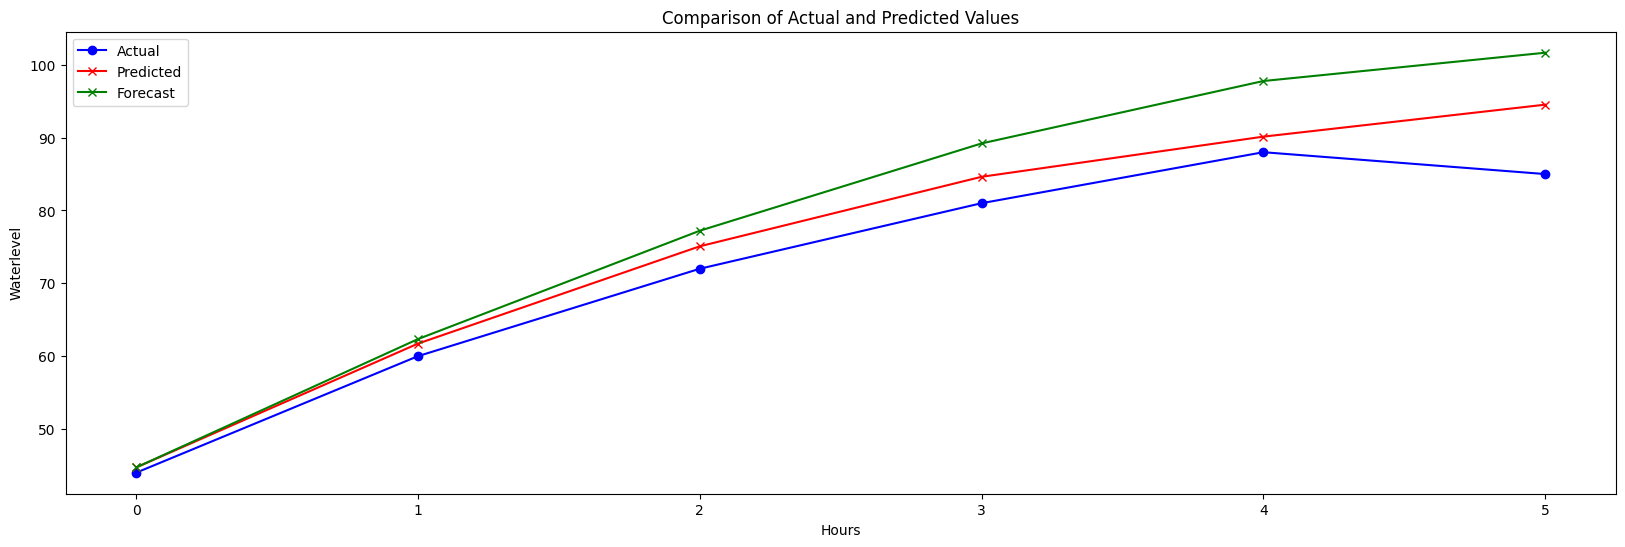

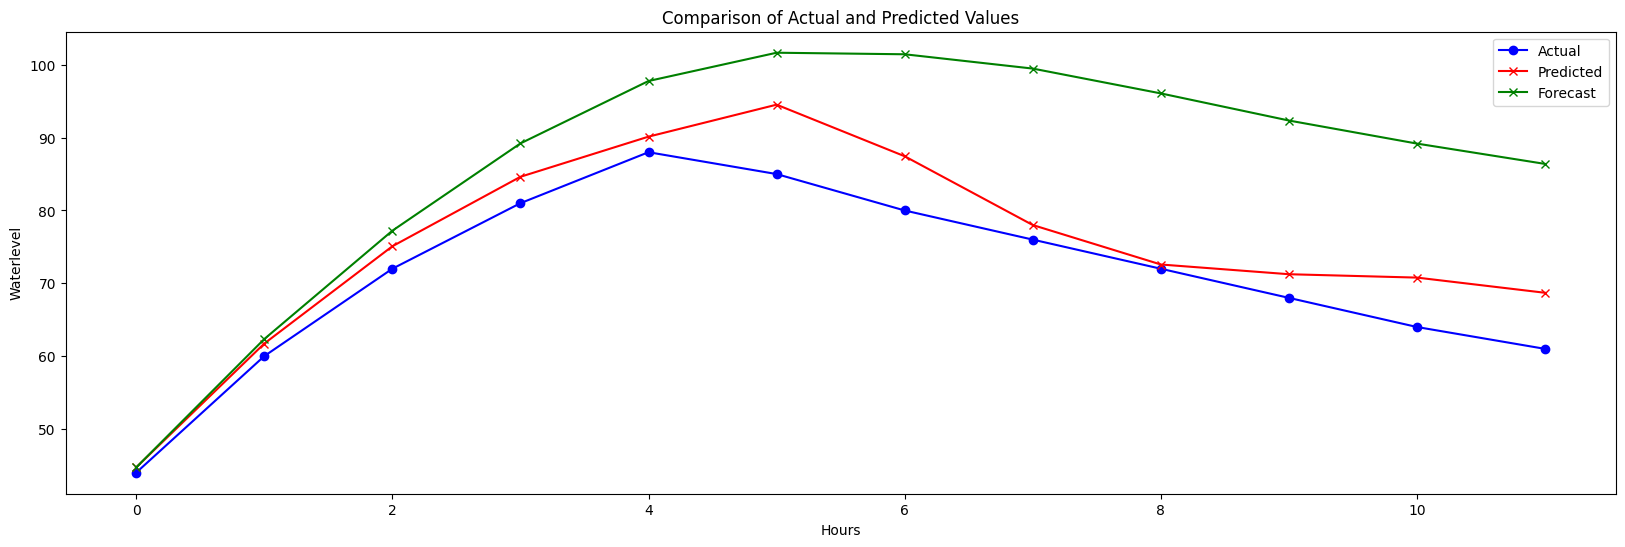

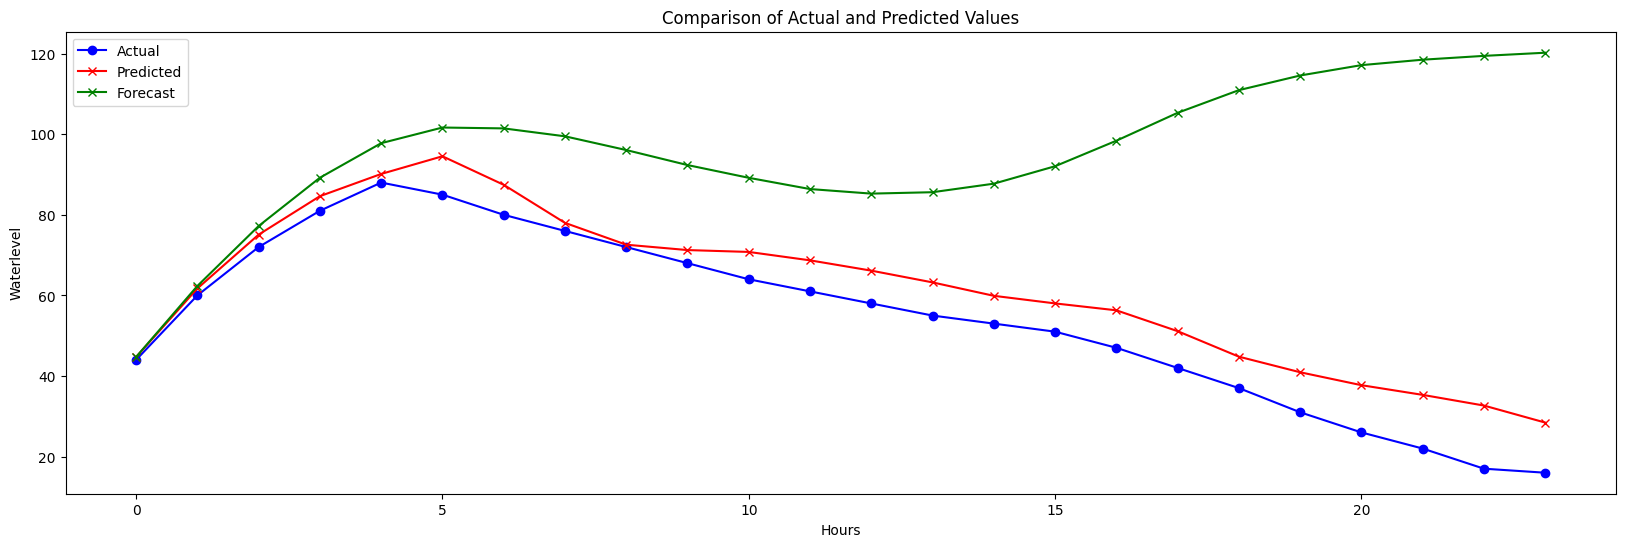

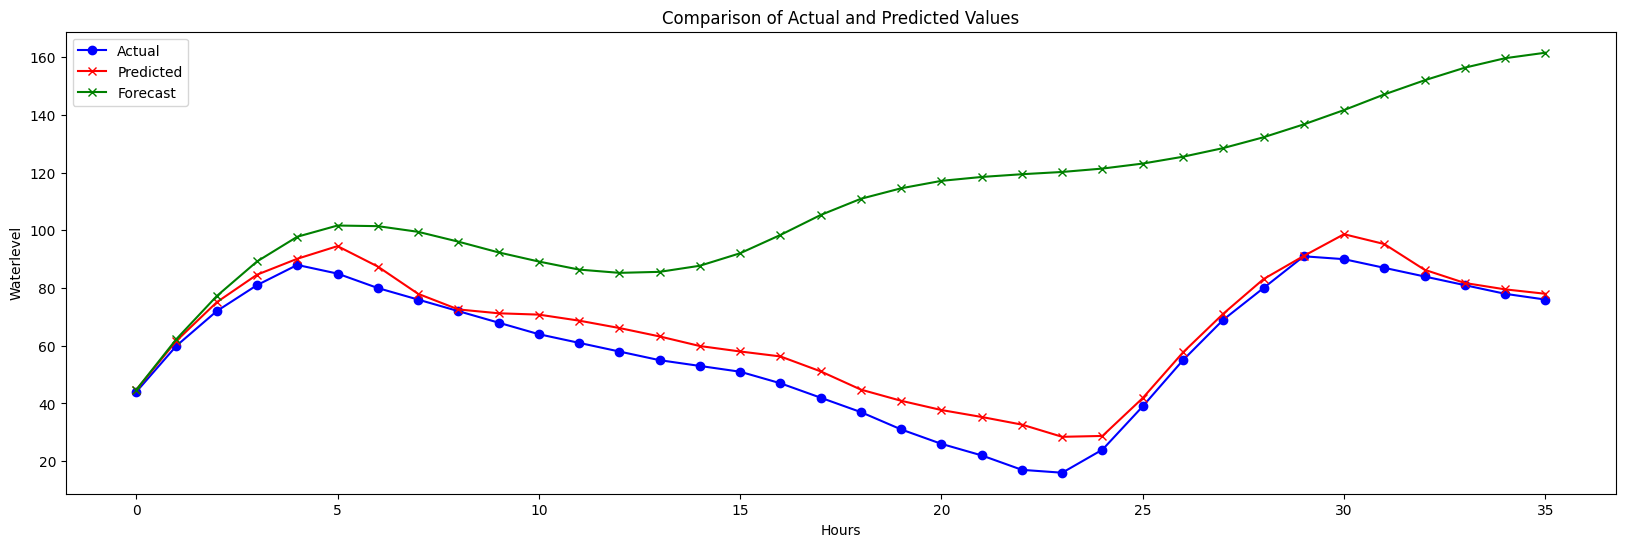

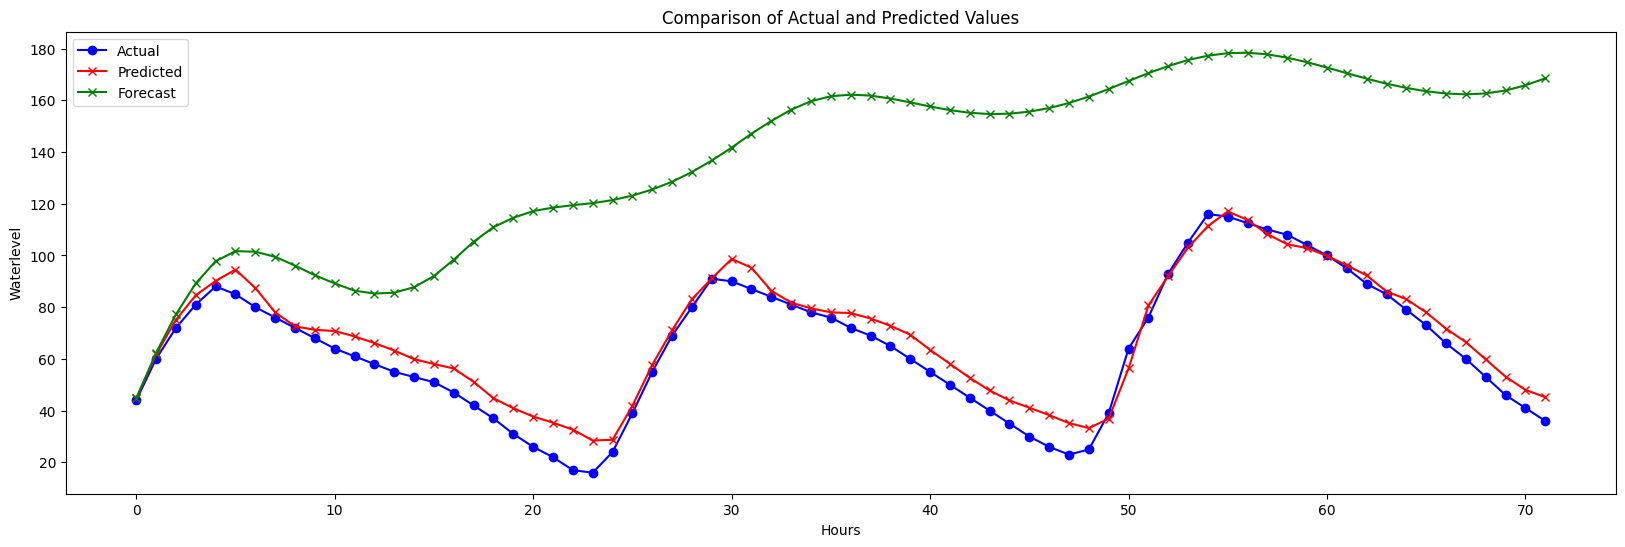

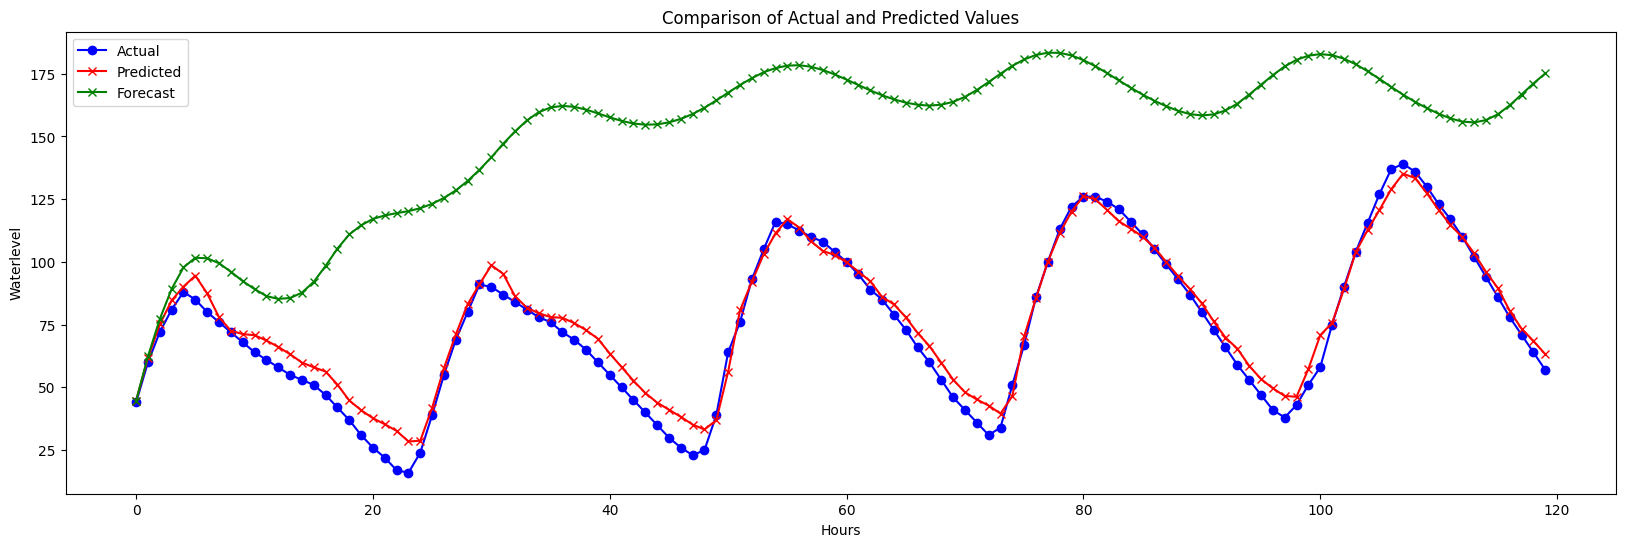

In [75]:
time_forecast = [3, 6,12,24,36,72,120]
for hours in time_forecast:
    plt.figure(figsize=(20, 6))
    
    plt.plot(y_test_original[time : time + hours].flatten(), label='Actual', color='blue', marker='o')
    plt.plot(y_pred_original[: hours], label='Predicted', color='red', marker='x')
    plt.plot(y_fc_original[: hours].flatten(), label='Forecast', color='green', marker='x')
    plt.title('Comparison of Actual and Predicted Values')
    plt.xlabel('Hours')
    plt.ylabel('Waterlevel')
    plt.legend()

    plt.show()

In [76]:
time_forecast = [3,  6, 12, 24, 36, 72, 120]
for hours in time_forecast:
    metrics = calculate_metrics(y_test_original[time : time + hours].flatten(), y_fc_original[:hours].flatten())
    for metric, value in metrics.items():
        print(f'Using model LSTM {hours} hours {metric}: {value}')

    print('\n')

Using model LSTM 3 hours MAE: 2.760773395498589
Using model LSTM 3 hours RMSE: 3.3292129048654178
Using model LSTM 3 hours MSE: 11.083658565922432
Using model LSTM 3 hours R: 0.9994381838371643
Using model LSTM 3 hours SIM: 0.9135326242861747
Using model LSTM 3 hours FSD: 1.9739178571825495
Using model LSTM 3 hours NSE: 0.9157492169820085


Using model LSTM 6 hours MAE: 7.152817147473492
Using model LSTM 6 hours RMSE: 8.883831651059985
Using model LSTM 6 hours MSE: 78.92246480437518
Using model LSTM 6 hours R: 0.9901222705609617
Using model LSTM 6 hours SIM: 0.8689639507334151
Using model LSTM 6 hours FSD: 1.9827295123560231
Using model LSTM 6 hours NSE: 0.6696268915165688


Using model LSTM 12 hours MAE: 15.568871490657324
Using model LSTM 12 hours RMSE: 18.109496172408516
Using model LSTM 12 hours MSE: 327.9538516184787
Using model LSTM 12 hours R: 0.8390663826607214
Using model LSTM 12 hours SIM: 0.7582049332885421
Using model LSTM 12 hours FSD: 1.9790930949176955
Using model LSTM 1